In [1]:
import sys
import subprocess

# This uses standard Python to install your packages
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "scikit-learn"])
print("Installation complete!")



Installation complete!


In [4]:
import pandas as pd

# Load the dataset 
df = pd.read_csv('C:\\Users\\HI\\Downloads\\4) house Prediction Data Set.csv')

# 1. View the first 5 rows of data
print("--- FIRST 5 ROWS ---")
display(df.head())

# 2. Check for missing values and column data types
print("\n--- DATASTRUCTURE & MISSING VALUES ---")
df.info()


--- FIRST 5 ROWS ---


,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...



--- DATASTRUCTURE & MISSING VALUES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 1 columns):
 #   Column                                                                                            Non-Null Count  Dtype 
---  ------                                                                                            --------------  ----- 
 0    0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00  505 non-null    object
dtypes: object(1)
memory usage: 4.1+ KB


In [ ]:
import pandas as pd

# 1. Define the official column names for the Boston dataset
# The raw dataset lacks a header row and uses space separators.
# We explicitly define the column names here to correctly split 
# the single text column into 14 individual numerical features.

column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE'
]

# 2. Reload the dataset, setting the separator to blank spaces
df = pd.read_csv(
    'C:\\Users\\HI\\Downloads\\4) house Prediction Data Set.csv', 
    header=None, 
    sep=r'\s+', 
    names=column_names
)

# 3. View the clean structural breakdown
print("--- CLEANED FIRST 5 ROWS ---")
display(df.head())

print("\n--- NEW STRUCTURAL BREAKDOWN ---")
df.info()


--- CLEANED FIRST 5 ROWS ---


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2



--- NEW STRUCTURAL BREAKDOWN ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate your features (X) from the target price (y)
X = df.drop(columns=['PRICE'])
y = df['PRICE']

# 2. Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the numbers so features with large values don't overpower the rest
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- TASK 1 COMPLETE ---")
print(f"Training features size: {X_train_scaled.shape}")
print(f"Testing features size: {X_test_scaled.shape}")
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

--- TASK 1 COMPLETE ---
Training features size: (404, 13)
Testing features size: (102, 13)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 2. Make price predictions on the hidden test data
y_pred = model.predict(X_test_scaled)

# 3. Calculate how well your model performed
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- TASK 2 COMPLETE ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.2f}")


--- TASK 2 COMPLETE ---
Mean Squared Error (MSE): 24.29
R-squared Score (R2): 0.67


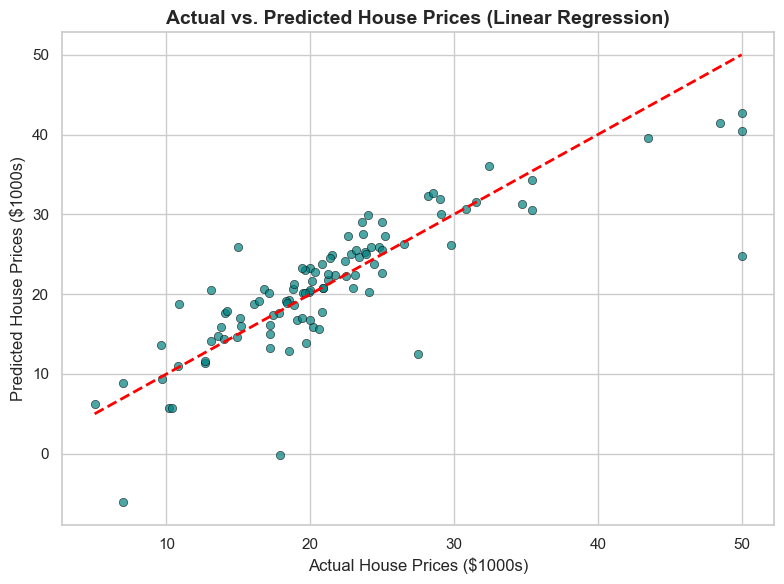

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean design style for the chart
sns.set_theme(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='teal', edgecolor='black')

# Add a perfect diagonal line (if predictions were 100% accurate, all points would sit on this line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

# Label the axes and title
plt.xlabel('Actual House Prices ($1000s)', fontsize=12)
plt.ylabel('Predicted House Prices ($1000s)', fontsize=12)
plt.title('Actual vs. Predicted House Prices (Linear Regression)', fontsize=14, fontweight='bold')

# Show the final plot
plt.tight_layout()
plt.show()


In [27]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Reload raw data to start fresh
column_names = [
    "CRIM",
    "ZN",
    "INDUS",
    "CHAS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "RAD",
    "TAX",
    "PTRATIO",
    "B",
    "LSTAT",
    "PRICE",
]
df_upgraded = pd.read_csv(
    "C:\\Users\\HI\\Downloads\\4) house Prediction Data Set.csv", header=None, sep=r"\s+", names=column_names
)

# 🔥 TRICK 1: Remove the capped price outliers (Prices exactly at 50.0)
df_upgraded = df_upgraded[df_upgraded["PRICE"] < 50.0]

# 2. Separate features and target
X_up = df_upgraded.drop(columns=["PRICE"])
y_up = df_upgraded["PRICE"]

# 🔥 TRICK 2: Create a non-linear feature using standard pandas/numpy mathematical syntax
# This helps the linear model understand the curved relationship of the 'LSTAT' column
X_up["LSTAT_log"] = np.log1p(X_up["LSTAT"])

# 3. Split the upgraded data (Using the exact same random state for consistency)
X_train_up, X_test_up, y_train_up, y_test_up = train_test_split(
    X_up, y_up, test_size=0.2, random_state=42
)

# 4. Scale your upgraded features using scikit-learn
scaler_up = StandardScaler()
X_train_scaled_up = scaler_up.fit_transform(X_train_up)
X_test_scaled_up = scaler_up.transform(X_test_up)

# 5. Retrain the exact same Linear Regression model
model_up = LinearRegression()
model_up.fit(X_train_scaled_up, y_train_up)

# 6. Make new predictions
y_pred_up = model_up.predict(X_test_scaled_up)

# 7. Evaluate your brilliant upgraded scores
mse_up = mean_squared_error(y_test_up, y_pred_up)
r2_up = r2_score(y_test_up, y_pred_up)

print("🚀 UPGRADED MODEL RESULTS 🚀")
print(f"New Mean Squared Error (MSE): {mse_up:.2f}")
print(f"New R-squared Score (R2): {r2_up:.2f}")


🚀 UPGRADED MODEL RESULTS 🚀
New Mean Squared Error (MSE): 10.26
New R-squared Score (R2): 0.80


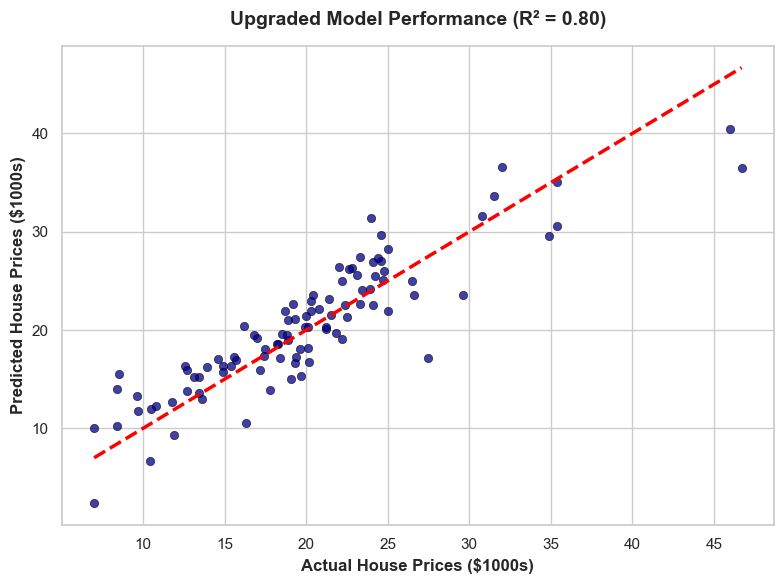

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a highly professional design style
sns.set_theme(style="whitegrid")

# Create the scatter plot using your upgraded variables
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_up, y=y_pred_up, alpha=0.75, color='darkblue', edgecolor='black')

# Add the perfect diagonal line
plt.plot([y_test_up.min(), y_test_up.max()], [y_test_up.min(), y_test_up.max()], color='red', lw=2.5, linestyle='--')

# Labels and layout styling
plt.xlabel('Actual House Prices ($1000s)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted House Prices ($1000s)', fontsize=12, fontweight='bold')
plt.title('Upgraded Model Performance (R² = 0.80)', fontsize=14, fontweight='bold', pad=15)

# Display the final plot
plt.tight_layout()
plt.show()
